<h3>Extracting Features</h3>
Using ConvNeXT Large model to get the features from the image snapshots.

Extracting features from snapshot...


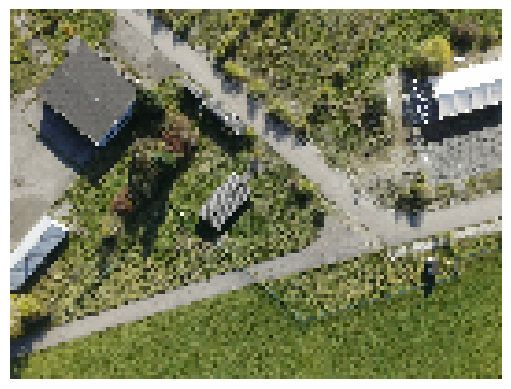

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Extracting features from image 2...


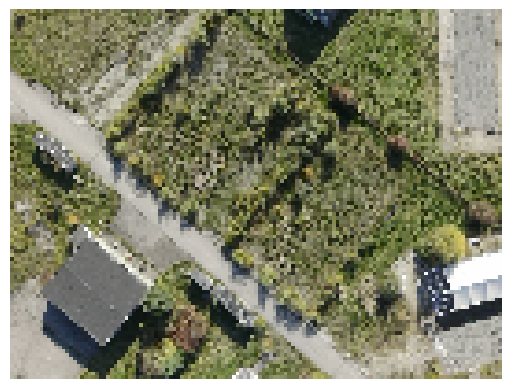

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
Feature vector size: 768
Cosine similarity between images: 0.6938
Medium similarity - possibly related location


In [ ]:
import tensorflow as tf
from tensorflow.keras.applications.convnext import ConvNeXtTiny
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.convnext import preprocess_input
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

# Initialize ConvNeXt Small model (without top classification layer)
model = ConvNeXtTiny(weights='imagenet', include_top=False, pooling='avg')

def load_and_preprocess_image(img_path):
    """Load and preprocess image for ConvNeXt"""
    img = image.load_img(img_path, target_size=(100, 133))
    plt.imshow(img)
    plt.axis('off')
    plt.show()
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    return preprocess_input(img_array)

def extract_features(img_path):
    """Extract features from image using ConvNeXt Small"""
    preprocessed_img = load_and_preprocess_image(img_path)
    features = model.predict(preprocessed_img)
    return features.flatten()

# Example usage with two images
# Replace these paths with your actual image paths
snapshot = "data/train_data/train_images/0013.JPG"
patch_test = "data/train_data/train_images/0014.JPG"

# Extract features from both images
print("Extracting features from snapshot...")
features1 = extract_features(snapshot)

print("Extracting features from image 2...")
features2 = extract_features(patch_test)

# Calculate similarity between features
similarity = cosine_similarity([features1], [features2])[0][0]

print(f"Feature vector size: {len(features1)}")
print(f"Cosine similarity between images: {similarity:.4f}")

# Higher similarity (closer to 1) suggests images might be from similar locations
if similarity > 0.8:
    print("High similarity - likely same or nearby location")
elif similarity > 0.6:
    print("Medium similarity - possibly related location")
else:
    print("Low similarity - likely different locations")

In [ ]:
def rank_patches_by_similarity(snapshot_features, patch_features_list):
    """Rank patches based on similarity to snapshot features"""
    similarities = []
    for features in patch_features_list:
        sim = cosine_similarity([snapshot_features], [features])[0][0]
        similarities.append(sim)
    return sorted(enumerate(similarities), key=lambda x: x[1], reverse=True)